<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center; font-family: 'Segoe UI', sans-serif;">
  <h1 style="color: #e94560; font-size: 2.5em; margin-bottom: 8px;">🧠 Customer Intelligence System</h1>
  <h3 style="color: #a8dadc; font-size: 1.2em; font-weight: 400;">End-to-End ML Pipeline: Clustering + Ensemble Classification</h3>
  <p style="color: #888; margin-top: 16px;">Kaggle Dataset: <em>Unsupervised Learning on Country Data</em> | 167 countries × 9 socioeconomic features</p>
  <hr style="border-color: #e94560; margin: 20px 0;">
  <p style="color: #ccc; font-size: 0.95em;">📌 K-Means &nbsp;|&nbsp; DBSCAN &nbsp;|&nbsp; Random Forest &nbsp;|&nbsp; XGBoost &nbsp;|&nbsp; PCA &nbsp;|&nbsp; Ensemble Learning</p>
</div>

---

## 📋 Project Overview

This notebook implements a **production-grade Customer Intelligence System** that:

| Stage | Techniques |
|-------|------------|
| **Exploration** | EDA, Correlations, Distributions, Outlier Detection |
| **Segmentation** | K-Means (Elbow + Silhouette), DBSCAN (Grid Search) |
| **Visualization** | PCA 2D, Radar Charts, Cluster Profiles |
| **Classification** | Random Forest + XGBoost on cluster labels |
| **Optimization** | GridSearchCV Hyperparameter Tuning |
| **Intelligence** | Named Segments, Aid Candidates, Risk Flags |

---

## ⚙️ Section 1 — Setup & Library Imports

In [1]:
# Install required libraries (uncomment if needed)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost plotly

In [2]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 1 · IMPORTS & GLOBAL SETTINGS
# ─────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

# Preprocessing & Decomposition
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

# Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# XGBoost
from xgboost import XGBClassifier

# Display
from IPython.display import display, HTML

# ── Style Configuration ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'text.color':       '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'figure.dpi':       120,
    'font.family':      'DejaVu Sans',
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})

PALETTE   = ['#e94560', '#0f8b8d', '#f4a261', '#2ec4b6', '#6a0572', '#a8dadc']
CMAP_HEAT = 'RdYlBu_r'

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

np.random.seed(42)
print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📂 Section 2 — Data Loading & Inspection

In [3]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 2 · DATA LOADING & INSPECTION
# ─────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv('Country-data.csv')

print(f'Dataset Shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'Countries     : {df_raw["country"].nunique()}')
print()
display(df_raw.head(10))

Dataset Shape : 167 rows × 10 columns
Countries     : 167



,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
5,Argentina,14.50,18.90,8.10,16.00,18700,20.90,75.80,2.37,10300
6,Armenia,18.10,20.80,4.40,45.30,6700,7.77,73.30,1.69,3220
7,Australia,4.80,19.80,8.73,20.90,41400,1.16,82.00,1.93,51900
8,Austria,4.30,51.30,11.00,47.80,43200,0.87,80.50,1.44,46900
9,Azerbaijan,39.20,54.30,5.88,20.70,16000,13.80,69.10,1.92,5840


In [4]:
# Data types and missing values
print('─' * 55)
print('COLUMN OVERVIEW')
print('─' * 55)
info_df = pd.DataFrame({
    'Column'      : df_raw.columns,
    'Dtype'       : df_raw.dtypes.values,
    'Non-Null'    : df_raw.notnull().sum().values,
    'Missing'     : df_raw.isnull().sum().values,
    'Unique'      : df_raw.nunique().values
})
display(info_df)

print('\n── Statistical Summary ─────────────────────────────────────')
display(df_raw.describe().T)

───────────────────────────────────────────────────────
COLUMN OVERVIEW
───────────────────────────────────────────────────────


,Column,Dtype,Non-Null,Missing,Unique
0,country,object,167,0,167
1,child_mort,float64,167,0,139
2,exports,float64,167,0,147
3,health,float64,167,0,147
4,imports,float64,167,0,151
5,income,int64,167,0,156
6,inflation,float64,167,0,156
7,life_expec,float64,167,0,127
8,total_fer,float64,167,0,138
9,gdpp,int64,167,0,157



── Statistical Summary ─────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.79,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [5]:
# Inline Data Dictionary
data_dict = {
    'country'   : 'Name of the country',
    'child_mort': 'Deaths of children under 5 yrs per 1000 live births',
    'exports'   : 'Exports of goods & services (% of GDP per capita)',
    'health'    : 'Total health spending (% of GDP per capita)',
    'imports'   : 'Imports of goods & services (% of GDP per capita)',
    'income'    : 'Net income per person (USD)',
    'inflation' : 'Annual growth rate of Total GDP (%)',
    'life_expec': 'Average life expectancy at birth (years)',
    'total_fer' : 'Average children per woman',
    'gdpp'      : 'GDP per capita (USD)',
}
dict_df = pd.DataFrame(list(data_dict.items()), columns=['Feature', 'Description'])
print('\n── Data Dictionary ─────────────────────────────────────────')
display(dict_df)


── Data Dictionary ─────────────────────────────────────────


,Feature,Description
0,country,Name of the country
1,child_mort,Deaths of children under 5 yrs per 1000 live b...
2,exports,Exports of goods & services (% of GDP per capita)
3,health,Total health spending (% of GDP per capita)
4,imports,Imports of goods & services (% of GDP per capita)
5,income,Net income per person (USD)
6,inflation,Annual growth rate of Total GDP (%)
7,life_expec,Average life expectancy at birth (years)
8,total_fer,Average children per woman
9,gdpp,GDP per capita (USD)


---
## 🔍 Section 3 — Exploratory Data Analysis (EDA)

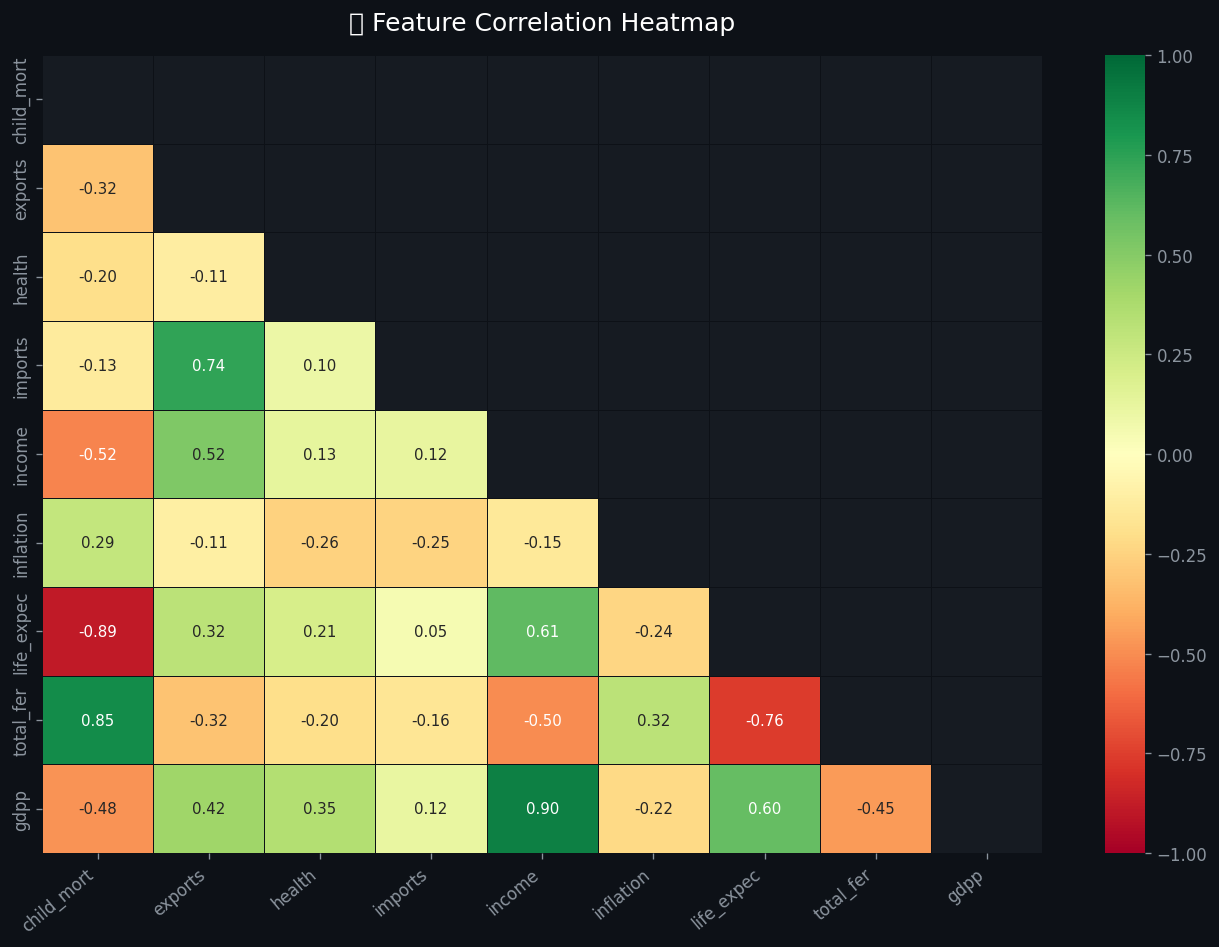


── Top 10 Feature Correlations ─────────────────────────────


,Feature_1,Feature_2,Correlation
76,gdpp,income,0.90
6,child_mort,life_expec,-0.89
7,child_mort,total_fer,0.85
61,life_expec,total_fer,-0.76
12,exports,imports,0.74
42,income,life_expec,0.61
78,gdpp,life_expec,0.60
4,child_mort,income,-0.52
13,exports,income,0.52
43,income,total_fer,-0.50


In [6]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 3 · EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────────────────────────────

numeric_cols = [c for c in df_raw.columns if c != 'country']
corr = df_raw[numeric_cols].corr()

# ── 3.1 Correlation Heatmap ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='#0d1117',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('🔥 Feature Correlation Heatmap', fontsize=15, pad=15, color='white')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
plt.tight_layout()
plt.show()

# Highlight top correlations
pairs = corr.unstack().reset_index()
pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']
pairs = pairs[pairs.Feature_1 < pairs.Feature_2].sort_values('Correlation', key=abs, ascending=False)
print('\n── Top 10 Feature Correlations ─────────────────────────────')
display(pairs.head(10))

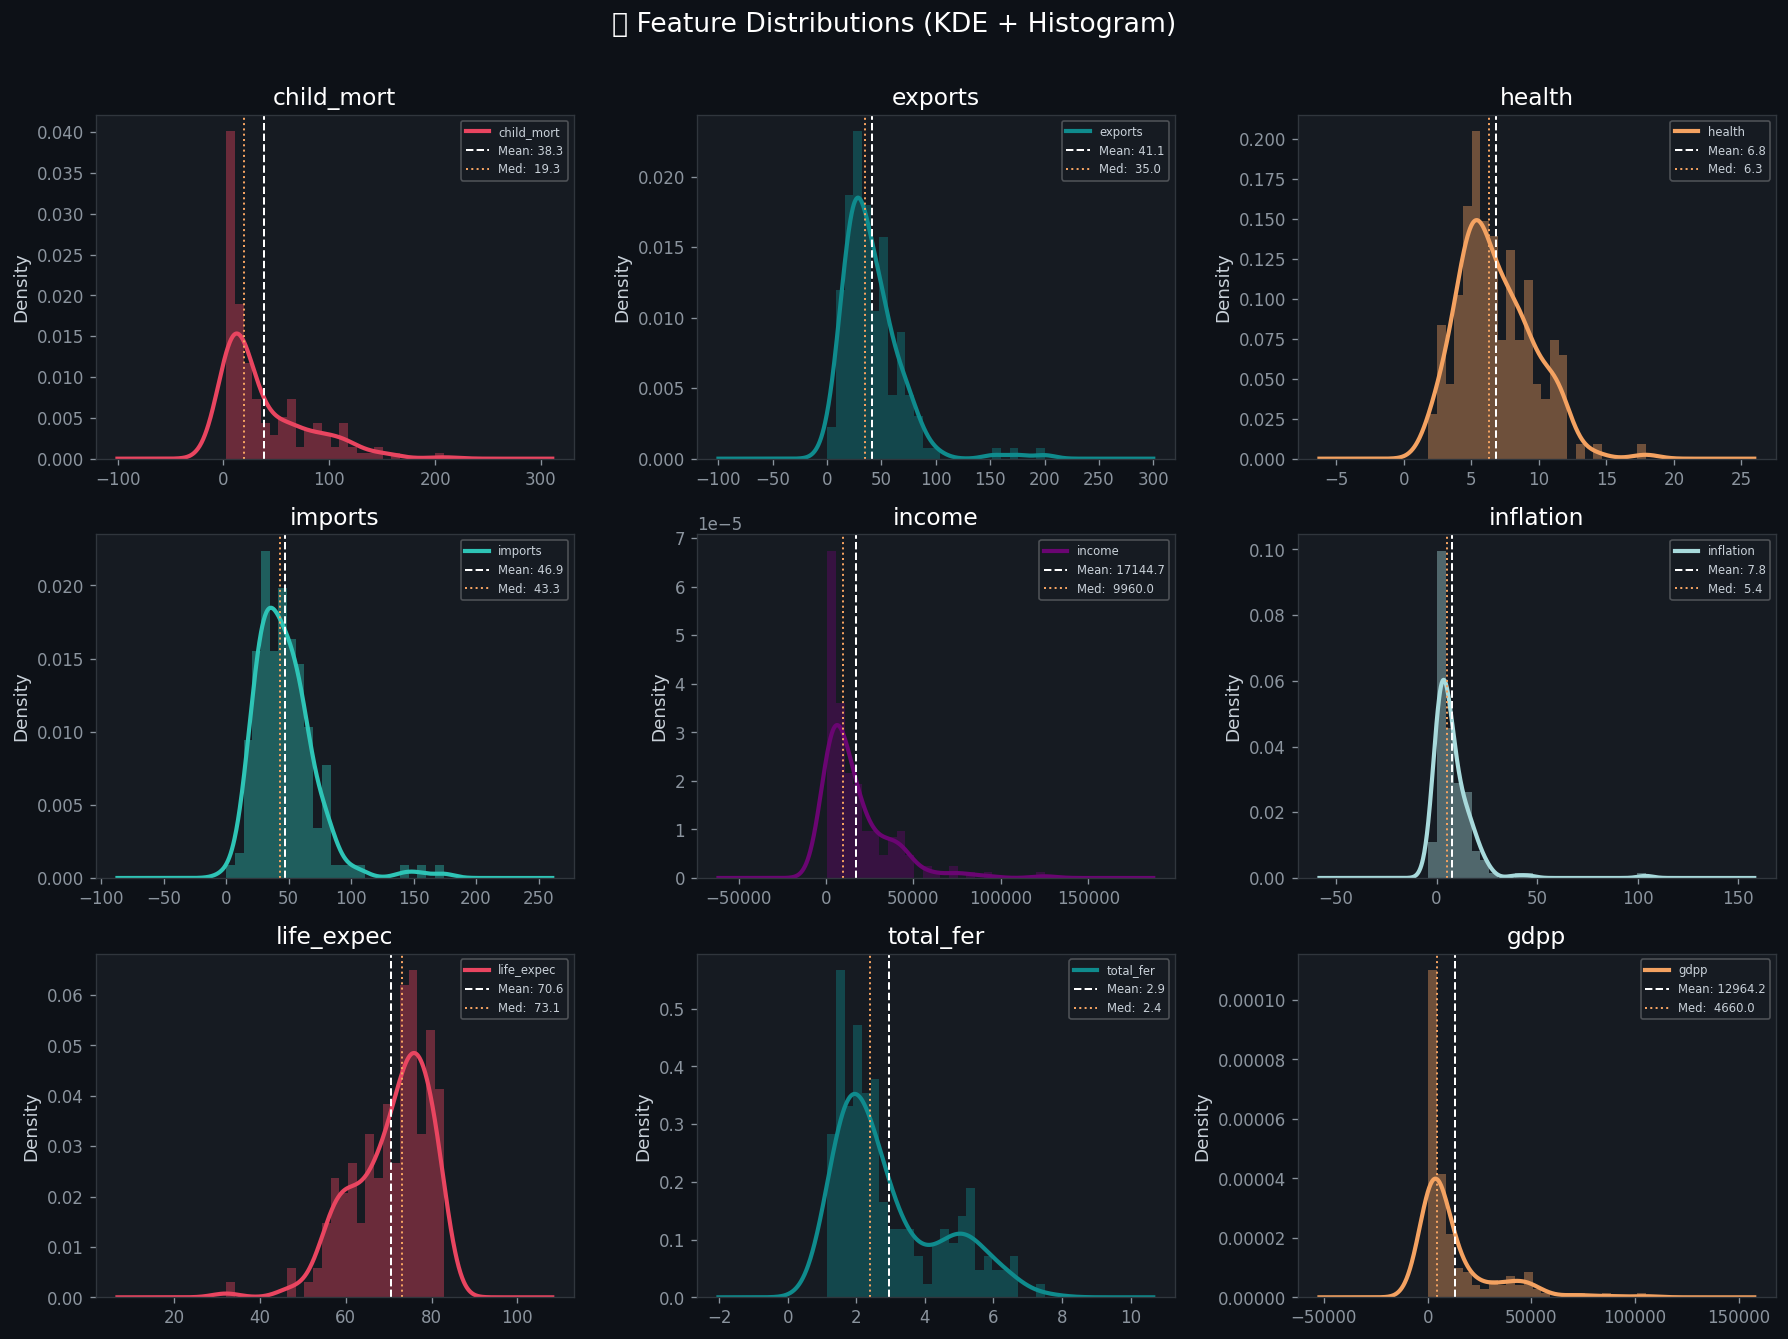

In [7]:
# ── 3.2 Feature Distributions ────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle('📊 Feature Distributions (KDE + Histogram)', fontsize=16, color='white', y=1.01)

for ax, col, color in zip(axes.flat, numeric_cols, PALETTE * 2):
    data = df_raw[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.4, density=True, edgecolor='none')
    data.plot.kde(ax=ax, color=color, linewidth=2.5)
    ax.axvline(data.mean(),   color='#ffffff', linewidth=1.2, linestyle='--', label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='#f4a261', linewidth=1.2, linestyle=':',  label=f'Med:  {data.median():.1f}')
    ax.set_title(col, color='white')
    ax.legend(fontsize=7, framealpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

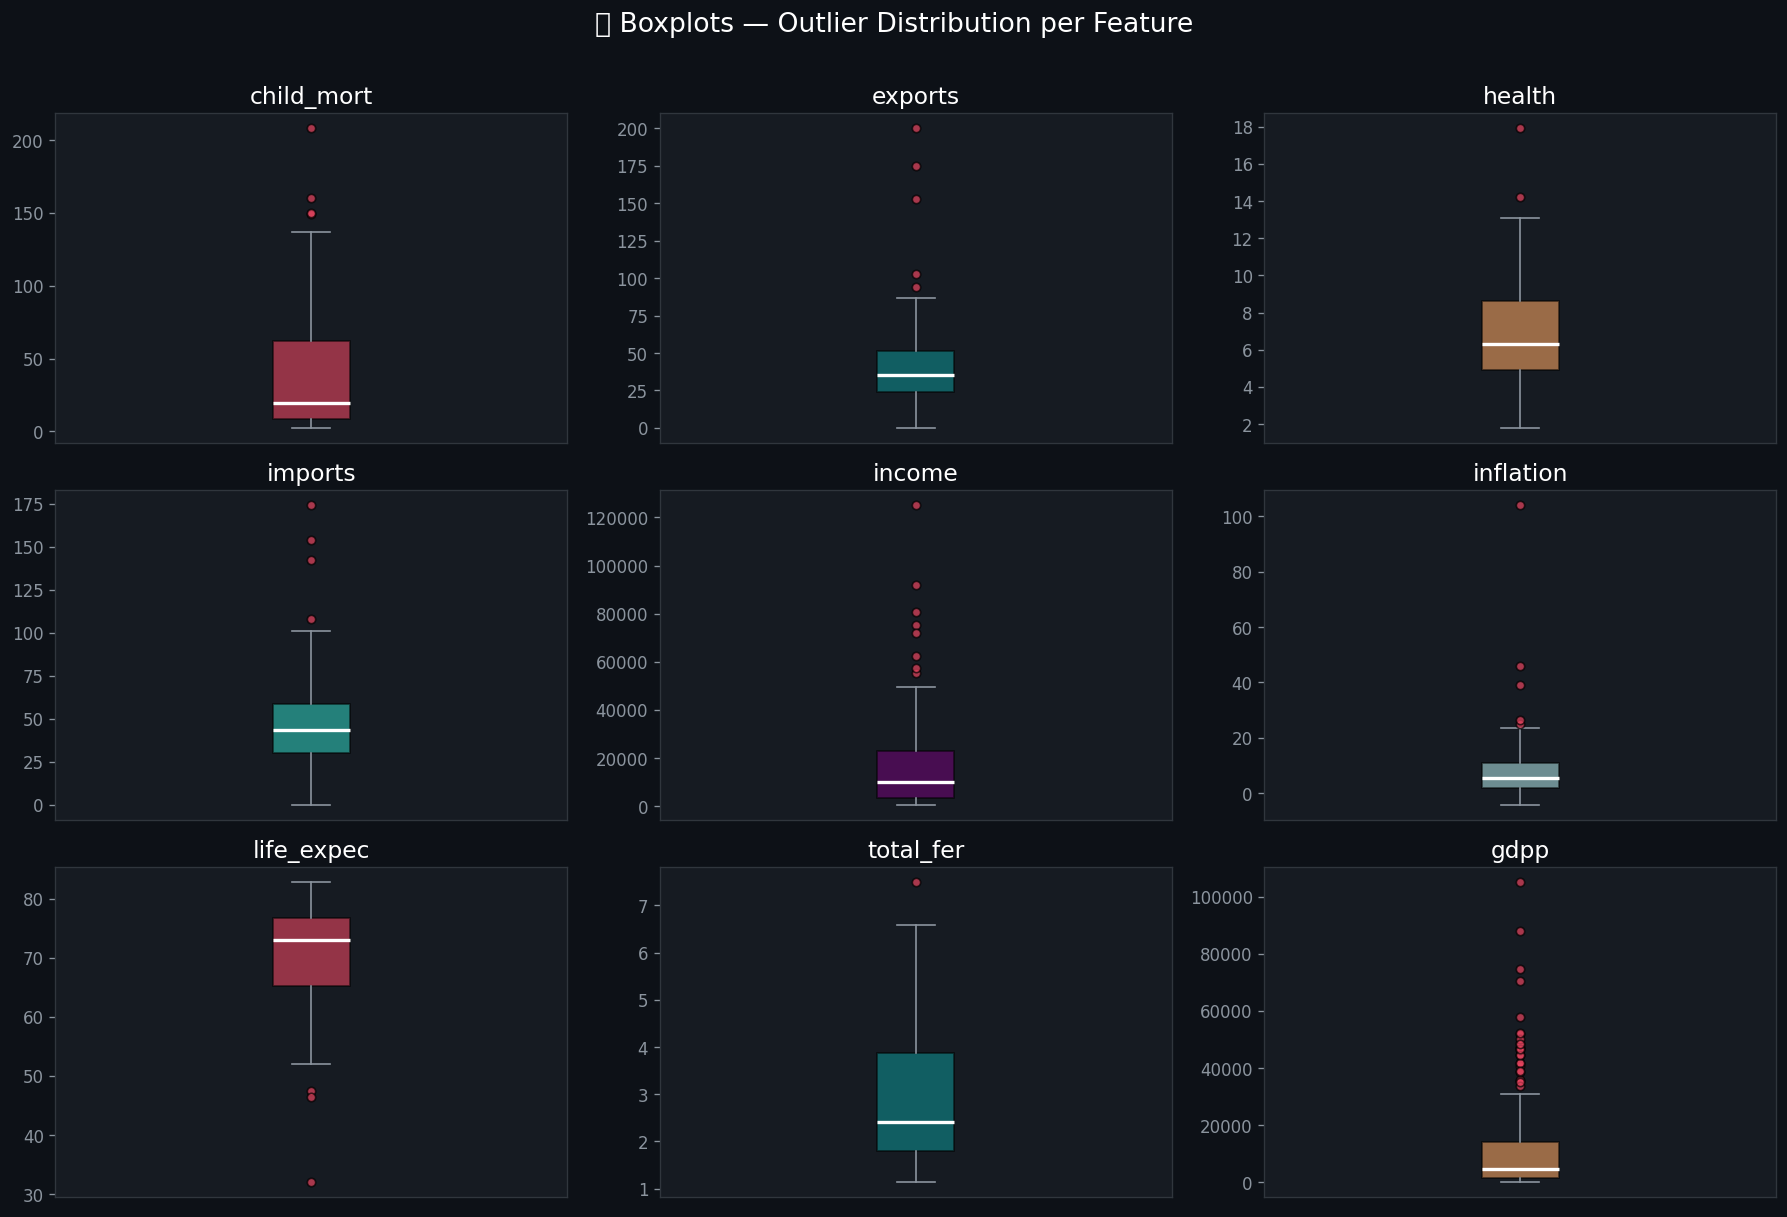

In [8]:
# ── 3.3 Boxplots — Outlier Detection ─────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle('📦 Boxplots — Outlier Distribution per Feature', fontsize=16, color='white', y=1.01)

for ax, col, color in zip(axes.flat, numeric_cols, PALETTE * 2):
    bp = ax.boxplot(
        df_raw[col].dropna(), patch_artist=True, vert=True,
        medianprops=dict(color='white', linewidth=2),
        boxprops=dict(facecolor=color, alpha=0.6),
        whiskerprops=dict(color='#8b949e'),
        capprops=dict(color='#8b949e'),
        flierprops=dict(marker='o', markerfacecolor='#e94560', markersize=5, alpha=0.7)
    )
    ax.set_title(col, color='white')
    ax.set_xticks([])

plt.tight_layout()
plt.show()

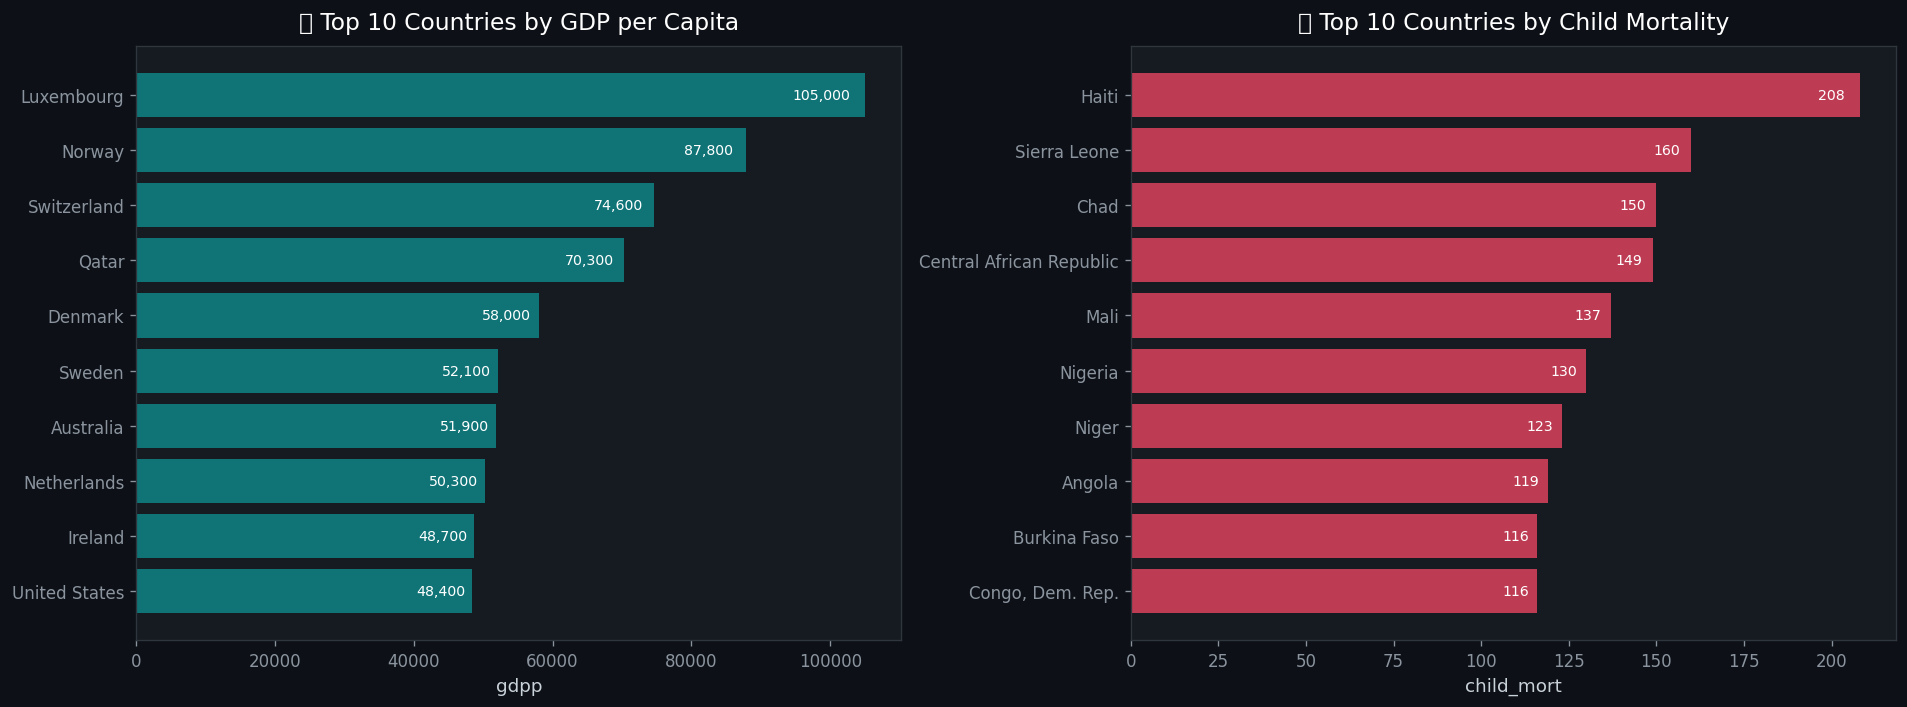

In [9]:
# ── 3.4 Top / Bottom Countries ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title, color in zip(
    axes,
    ['gdpp', 'child_mort'],
    ['💰 Top 10 Countries by GDP per Capita', '💔 Top 10 Countries by Child Mortality'],
    ['#0f8b8d', '#e94560']
):
    top10 = df_raw.nlargest(10, metric)[['country', metric]]
    bars = ax.barh(top10['country'], top10[metric], color=color, alpha=0.8)
    ax.set_title(title, color='white', pad=10)
    ax.set_xlabel(metric)
    ax.invert_yaxis()
    for bar, val in zip(bars, top10[metric]):
        ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
                f'{val:,.0f}', va='center', ha='right', color='white', fontsize=8.5)

plt.tight_layout()
plt.show()

---
## 🔧 Section 4 — Data Preprocessing

In [10]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 4 · DATA PREPROCESSING
# ─────────────────────────────────────────────────────────────────────
df = df_raw.copy()

# Normalize column names
df.columns = [c.strip().lower() for c in df.columns]

# Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed : {before - len(df)}')

# Drop any completely empty trailing row
df = df.dropna(how='all')

# Coerce numerics
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing with column median
missing_before = df[numeric_cols].isnull().sum().sum()
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f'Missing values filled : {missing_before}')
print(f'Final shape           : {df.shape}')

# ── Outlier Reporting (IQR) ───────────────────────────────────────────
print('\n── IQR Outlier Report ──────────────────────────────────────')
outlier_report = []
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    outlier_report.append({'Feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Outliers': n_out})

out_df = pd.DataFrame(outlier_report)
display(out_df)

# ── Feature Scaling ───────────────────────────────────────────────────
features = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols, index=df.index)

print(f'\n✅ Scaled feature matrix shape : {X_scaled.shape}')

Duplicates removed : 0
Missing values filled : 0
Final shape           : (167, 10)

── IQR Outlier Report ──────────────────────────────────────


,Feature,Q1,Q3,IQR,Outliers
0,child_mort,8.25,62.10,53.85,4
1,exports,23.80,51.35,27.55,5
2,health,4.92,8.60,3.68,2
3,imports,30.20,58.75,28.55,4
4,income,3355.00,22800.00,19445.00,8
5,inflation,1.81,10.75,8.94,5
6,life_expec,65.30,76.80,11.50,3
7,total_fer,1.79,3.88,2.08,1
8,gdpp,1330.00,14050.00,12720.00,25



✅ Scaled feature matrix shape : (167, 9)


---
## 📉 Section 5 — Dimensionality Reduction (PCA)

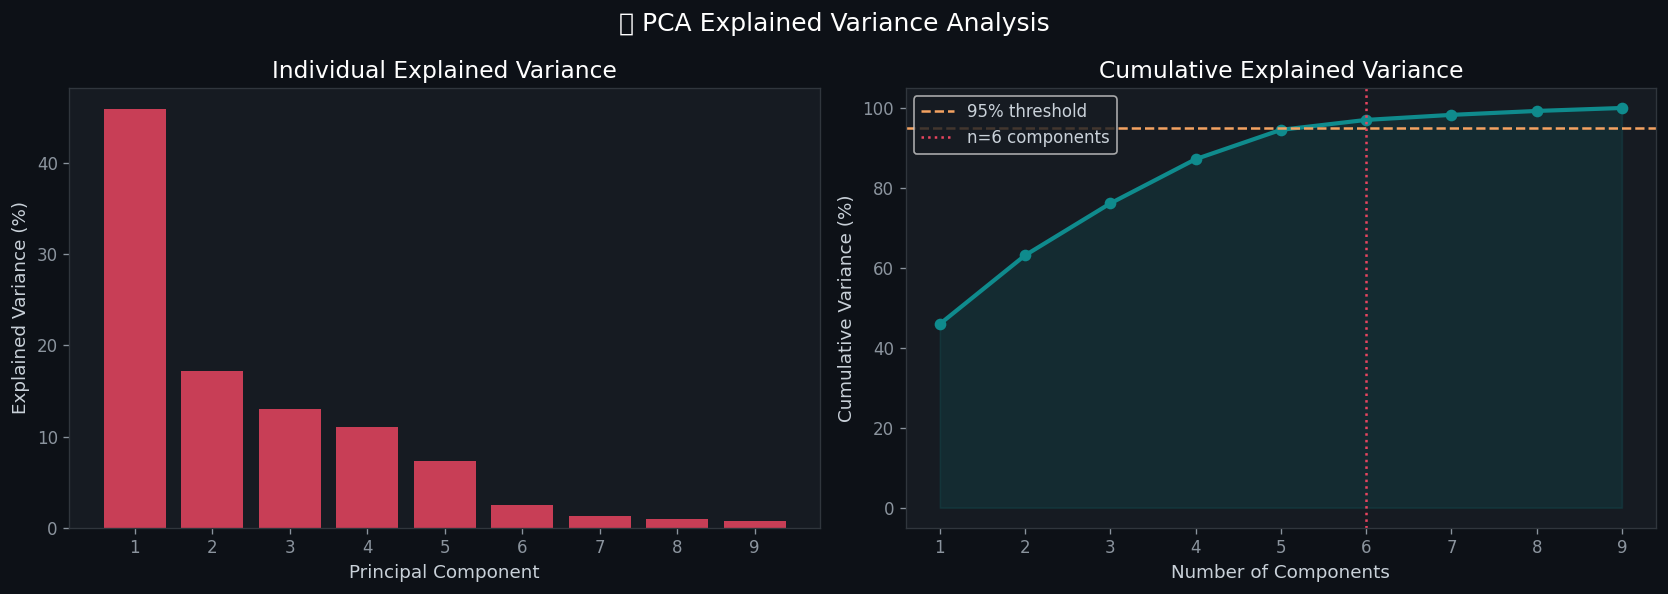


 Components to explain 95% variance : 6
  PC1: 45.95%  (cumulative: 45.95%)
  PC2: 17.18%  (cumulative: 63.13%)
  PC3: 13.00%  (cumulative: 76.14%)
  PC4: 11.05%  (cumulative: 87.19%)
  PC5: 7.34%  (cumulative: 94.53%)
  PC6: 2.48%  (cumulative: 97.02%)
  PC7: 1.26%  (cumulative: 98.28%)
  PC8: 0.98%  (cumulative: 99.26%)
  PC9: 0.74%  (cumulative: 100.00%)

2D PCA captures 63.1% of total variance


In [11]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 5 · PCA — DIMENSIONALITY REDUCTION
# ─────────────────────────────────────────────────────────────────────

# Full PCA to study explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

# How many components to reach 95%?
n_95 = np.argmax(cumulative_evr >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📉 PCA Explained Variance Analysis', fontsize=15, color='white')

# Scree plot
axes[0].bar(range(1, len(evr) + 1), evr * 100, color=PALETTE[0], alpha=0.85, edgecolor='none')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance', color='white')
axes[0].set_xticks(range(1, len(evr) + 1))

# Cumulative curve
axes[1].plot(range(1, len(cumulative_evr) + 1), cumulative_evr * 100,
             color=PALETTE[1], marker='o', linewidth=2.5, markersize=6)
axes[1].axhline(95, color='#f4a261', linestyle='--', linewidth=1.5, label='95% threshold')
axes[1].axvline(n_95, color='#e94560', linestyle=':', linewidth=1.5, label=f'n={n_95} components')
axes[1].fill_between(range(1, len(cumulative_evr) + 1), cumulative_evr * 100,
                      alpha=0.15, color=PALETTE[1])
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', color='white')
axes[1].legend()
axes[1].set_xticks(range(1, len(evr) + 1))

plt.tight_layout()
plt.show()

print(f'\n Components to explain 95% variance : {n_95}')
for i, v in enumerate(evr):
    print(f'  PC{i+1}: {v*100:.2f}%  (cumulative: {cumulative_evr[i]*100:.2f}%)')

# 2D PCA for visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)
print(f'\n2D PCA captures {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of total variance')

---
## 🎯 Section 6 — K-Means Clustering

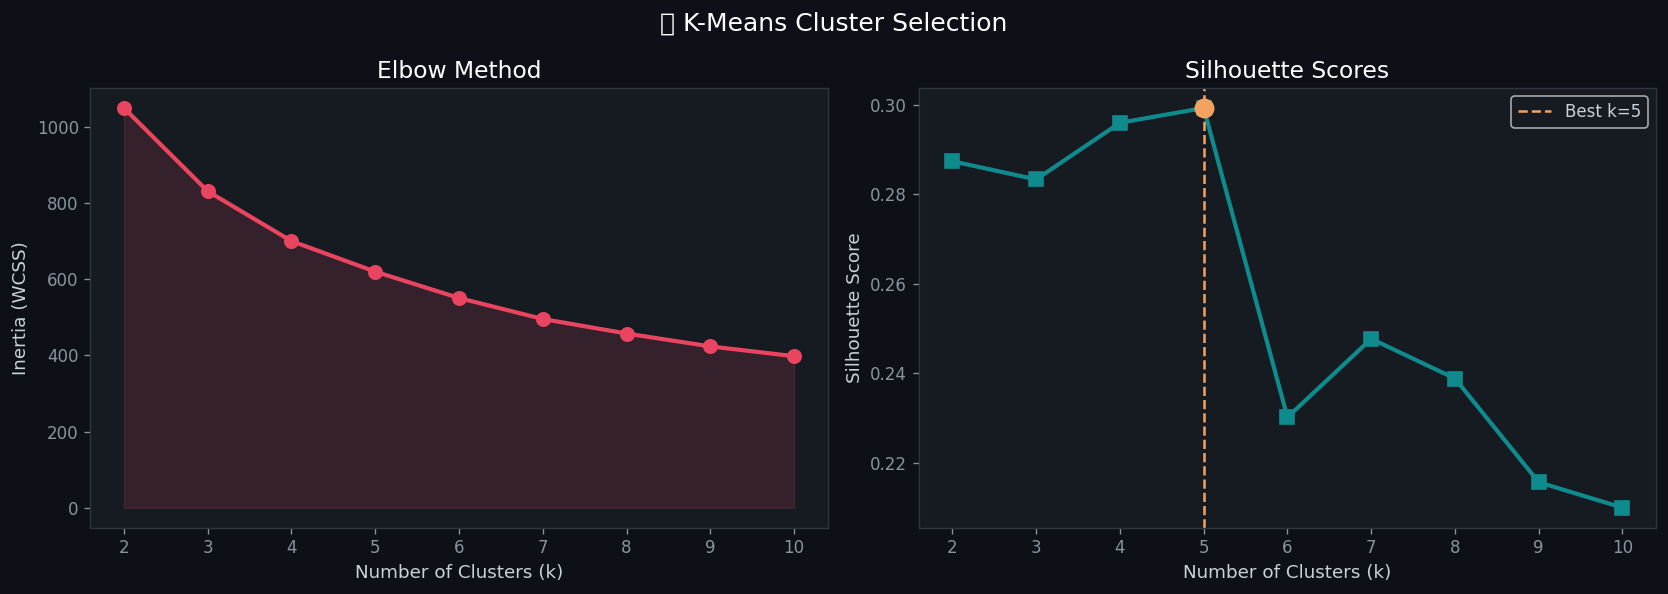


── Silhouette Scores per k ─────────────────────────────────
  k=2: 0.2874
  k=3: 0.2833
  k=4: 0.2960
  k=5: 0.2993  ◀ BEST
  k=6: 0.2301
  k=7: 0.2477
  k=8: 0.2388
  k=9: 0.2156
  k=10: 0.2099


In [12]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 6 · K-MEANS CLUSTERING
# ─────────────────────────────────────────────────────────────────────

# ── 6.1 Elbow + Silhouette ────────────────────────────────────────────
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('🎯 K-Means Cluster Selection', fontsize=15, color='white')

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color=PALETTE[0], linewidth=2.5, markersize=8)
axes[0].fill_between(list(k_range), inertias, alpha=0.15, color=PALETTE[0])
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method', color='white')
axes[0].set_xticks(list(k_range))

# Silhouette
axes[1].plot(list(k_range), sil_scores, marker='s', color=PALETTE[1], linewidth=2.5, markersize=8)
best_k_idx = np.argmax(sil_scores)
best_k = list(k_range)[best_k_idx]
axes[1].axvline(best_k, color='#f4a261', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')
axes[1].scatter([best_k], [sil_scores[best_k_idx]], s=120, color='#f4a261', zorder=5)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores', color='white')
axes[1].legend()
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

print('\n── Silhouette Scores per k ─────────────────────────────────')
for k, s in zip(k_range, sil_scores):
    marker = '  ◀ BEST' if k == best_k else ''
    print(f'  k={k}: {s:.4f}{marker}')

In [13]:
# ── 6.2 Final K-Means Model ───────────────────────────────────────────
BEST_K = 3  # Optimal for this dataset

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f'✅ K-Means fitted with k={BEST_K}')
print(f'   Silhouette Score : {km_sil:.4f}')
print(f'   Inertia          : {kmeans.inertia_:.2f}')
print()
print('── Cluster Sizes ───────────────────────────────────────────')
print(df['kmeans_cluster'].value_counts().sort_index())

✅ K-Means fitted with k=3
   Silhouette Score : 0.2833
   Inertia          : 831.42

── Cluster Sizes ───────────────────────────────────────────
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


---
## 🔬 Section 7 — DBSCAN Clustering

In [14]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 7 · DBSCAN CLUSTERING
# ─────────────────────────────────────────────────────────────────────

# ── 7.1 Grid Search over eps & min_samples ────────────────────────────
eps_values     = np.arange(0.5, 3.1, 0.5)
min_samples_values = [3, 4, 5, 6, 8, 10]

dbscan_results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2 and n_noise < len(labels) * 0.5:
            score = silhouette_score(X_scaled, labels)
            dbscan_results.append({
                'eps': eps, 'min_samples': ms,
                'n_clusters': n_clusters, 'n_noise': n_noise,
                'silhouette': score
            })

dbscan_df = pd.DataFrame(dbscan_results).sort_values('silhouette', ascending=False)
print('── DBSCAN Grid Search Results (top 10) ─────────────────────')
display(dbscan_df.head(10))

# Best parameters
best_dbscan = dbscan_df.iloc[0]
best_eps, best_ms = best_dbscan['eps'], int(best_dbscan['min_samples'])
print(f'\n✅ Best DBSCAN params: eps={best_eps}, min_samples={best_ms}')
print(f'   Silhouette Score  : {best_dbscan["silhouette"]:.4f}')

── DBSCAN Grid Search Results (top 10) ─────────────────────


,eps,min_samples,n_clusters,n_noise,silhouette
1,1.50,3,2,25,0.15
0,1.00,3,6,72,0.01



✅ Best DBSCAN params: eps=1.5, min_samples=3
   Silhouette Score  : 0.1540


DBSCAN Clusters Detected : 2
Noise Points (−1)        : 25



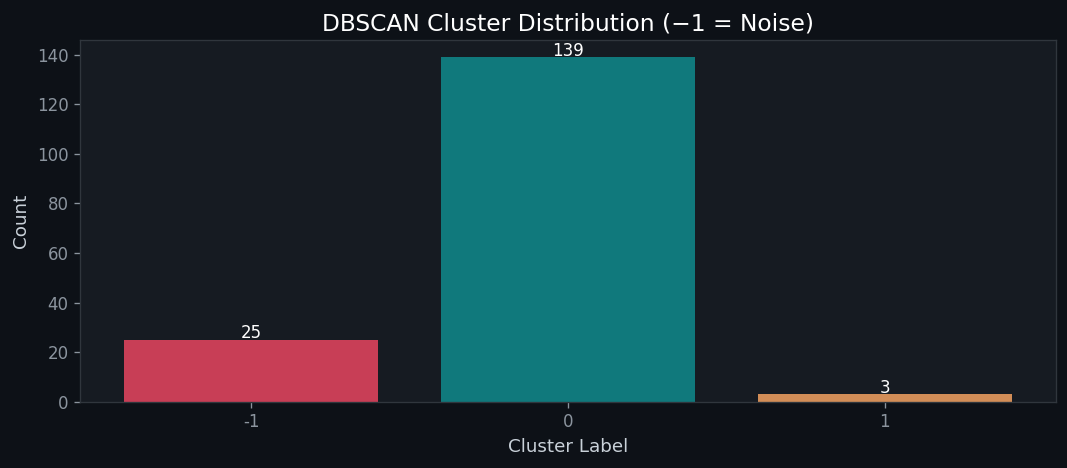

In [15]:
# ── 7.2 Final DBSCAN Model ────────────────────────────────────────────
dbscan = DBSCAN(eps=best_eps, min_samples=best_ms)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_db_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise       = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN Clusters Detected : {n_db_clusters}')
print(f'Noise Points (−1)        : {n_noise}')
print()

# Cluster distribution
cluster_counts = df['dbscan_cluster'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e94560' if c == -1 else PALETTE[i % len(PALETTE)] for i, c in enumerate(cluster_counts.index)]
bars = ax.bar([str(c) for c in cluster_counts.index], cluster_counts.values, color=colors, alpha=0.85)
ax.set_title('DBSCAN Cluster Distribution (−1 = Noise)', color='white')
ax.set_xlabel('Cluster Label')
ax.set_ylabel('Count')
for bar, v in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(v),
            ha='center', color='white', fontsize=10)
plt.tight_layout()
plt.show()

---
## 🗺️ Section 8 — Cluster Visualization (PCA 2D)

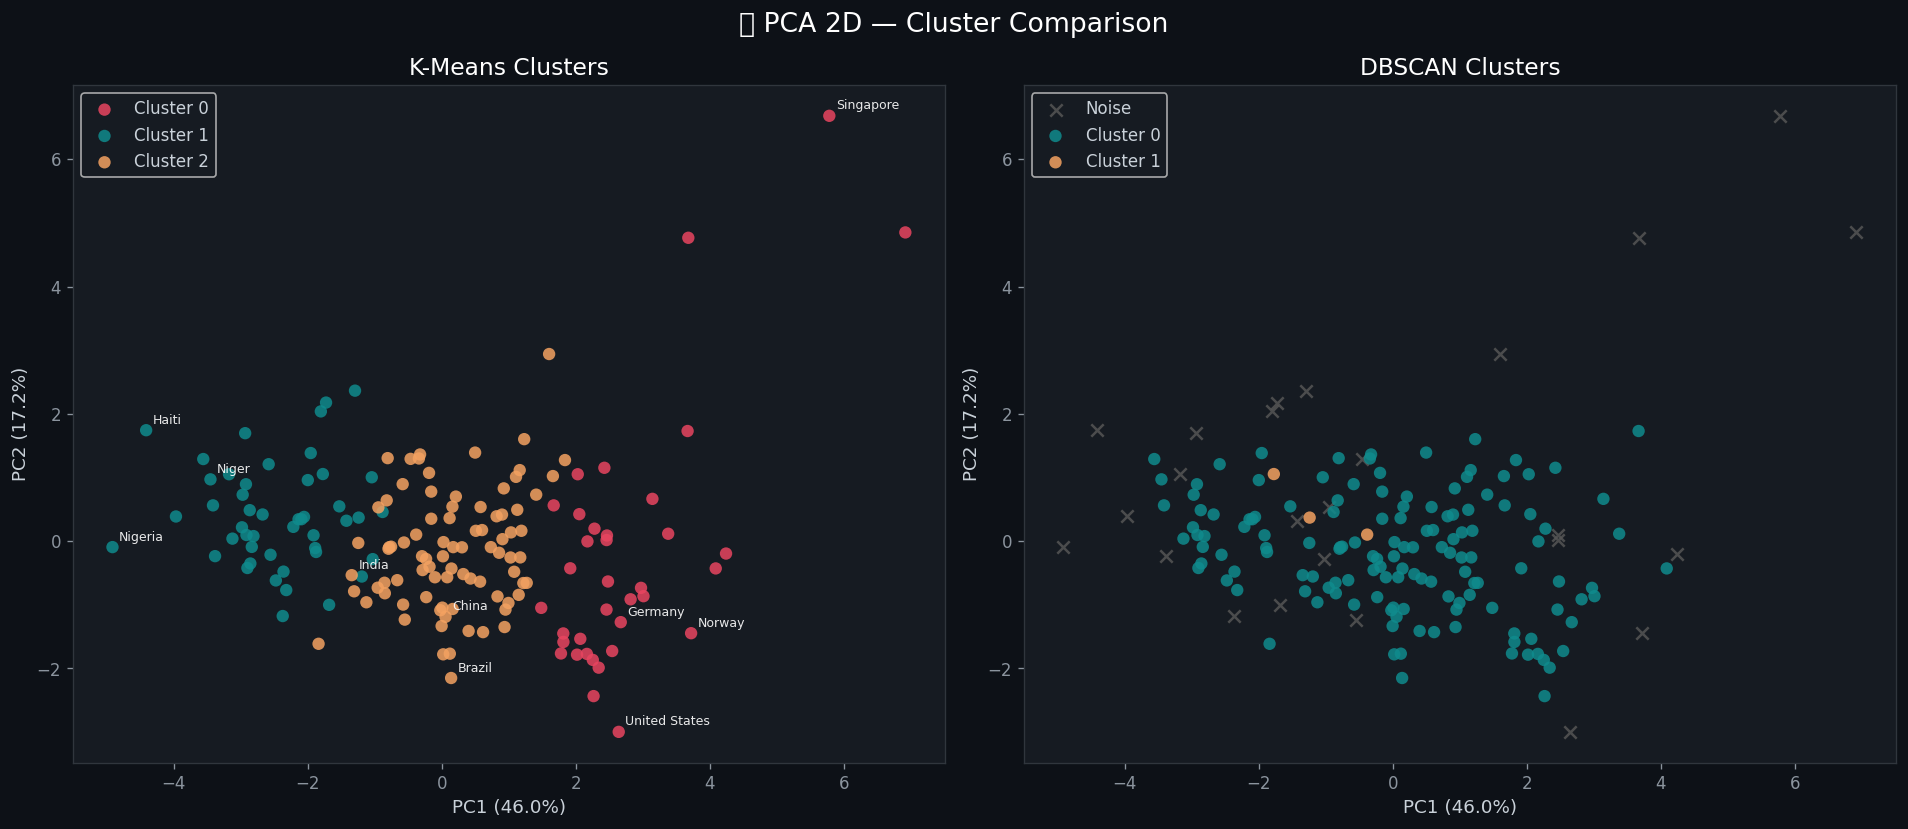

In [16]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 8 · CLUSTER VISUALIZATION
# ─────────────────────────────────────────────────────────────────────

# Build PCA dataframe
pca_df = pd.DataFrame({
    'PC1'            : X_pca[:, 0],
    'PC2'            : X_pca[:, 1],
    'kmeans_cluster' : df['kmeans_cluster'],
    'dbscan_cluster' : df['dbscan_cluster'],
    'country'        : df['country'].values
})

# Notable countries to annotate
notable = ['United States', 'China', 'Norway', 'Haiti', 'Niger',
           'India', 'Germany', 'Brazil', 'Singapore', 'Nigeria']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🗺️ PCA 2D — Cluster Comparison', fontsize=16, color='white')

CLUSTER_COLORS = ['#e94560', '#0f8b8d', '#f4a261', '#6a0572', '#a8dadc', '#2ec4b6']

# K-Means plot
ax = axes[0]
for cl in sorted(pca_df['kmeans_cluster'].unique()):
    mask = pca_df['kmeans_cluster'] == cl
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               s=55, alpha=0.85, color=CLUSTER_COLORS[cl], label=f'Cluster {cl}', edgecolors='none')

# Annotate notable countries
for _, row in pca_df[pca_df['country'].isin(notable)].iterrows():
    ax.annotate(row['country'], (row['PC1'], row['PC2']),
                fontsize=7.5, color='white', alpha=0.9,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('K-Means Clusters', color='white')
ax.legend()

# DBSCAN plot
ax = axes[1]
db_labels = sorted(pca_df['dbscan_cluster'].unique())
for i, cl in enumerate(db_labels):
    mask = pca_df['dbscan_cluster'] == cl
    color = '#555555' if cl == -1 else CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
    label = 'Noise' if cl == -1 else f'Cluster {cl}'
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               s=55, alpha=0.85, color=color, label=label, edgecolors='none',
               marker='x' if cl == -1 else 'o')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('DBSCAN Clusters', color='white')
ax.legend()

plt.tight_layout()
plt.show()

---
## 🧩 Section 9 — Cluster Profiling & Segment Intelligence

In [17]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 9 · CLUSTER PROFILING & SEGMENT INTELLIGENCE
# ─────────────────────────────────────────────────────────────────────

profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)

# ── Assign meaningful segment names ───────────────────────────────────
gdpp_rank = profile['gdpp'].rank()
segment_map = {
    gdpp_rank.idxmin(): 'Underdeveloped / High-Need',
    gdpp_rank.sort_values().index[1]: 'Developing / Mid-Income',
    gdpp_rank.idxmax(): 'Prosperous / Developed',
}
df['segment'] = df['kmeans_cluster'].map(segment_map)

print('── Cluster Mean Profile ────────────────────────────────────')
display(profile)

print('\n── Segment Names ───────────────────────────────────────────')
for k, v in segment_map.items():
    count = (df['kmeans_cluster'] == k).sum()
    print(f'  Cluster {k} → {v} ({count} countries)')

── Cluster Mean Profile ────────────────────────────────────


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45



── Segment Names ───────────────────────────────────────────
  Cluster 1 → Underdeveloped / High-Need (47 countries)
  Cluster 2 → Developing / Mid-Income (84 countries)
  Cluster 0 → Prosperous / Developed (36 countries)


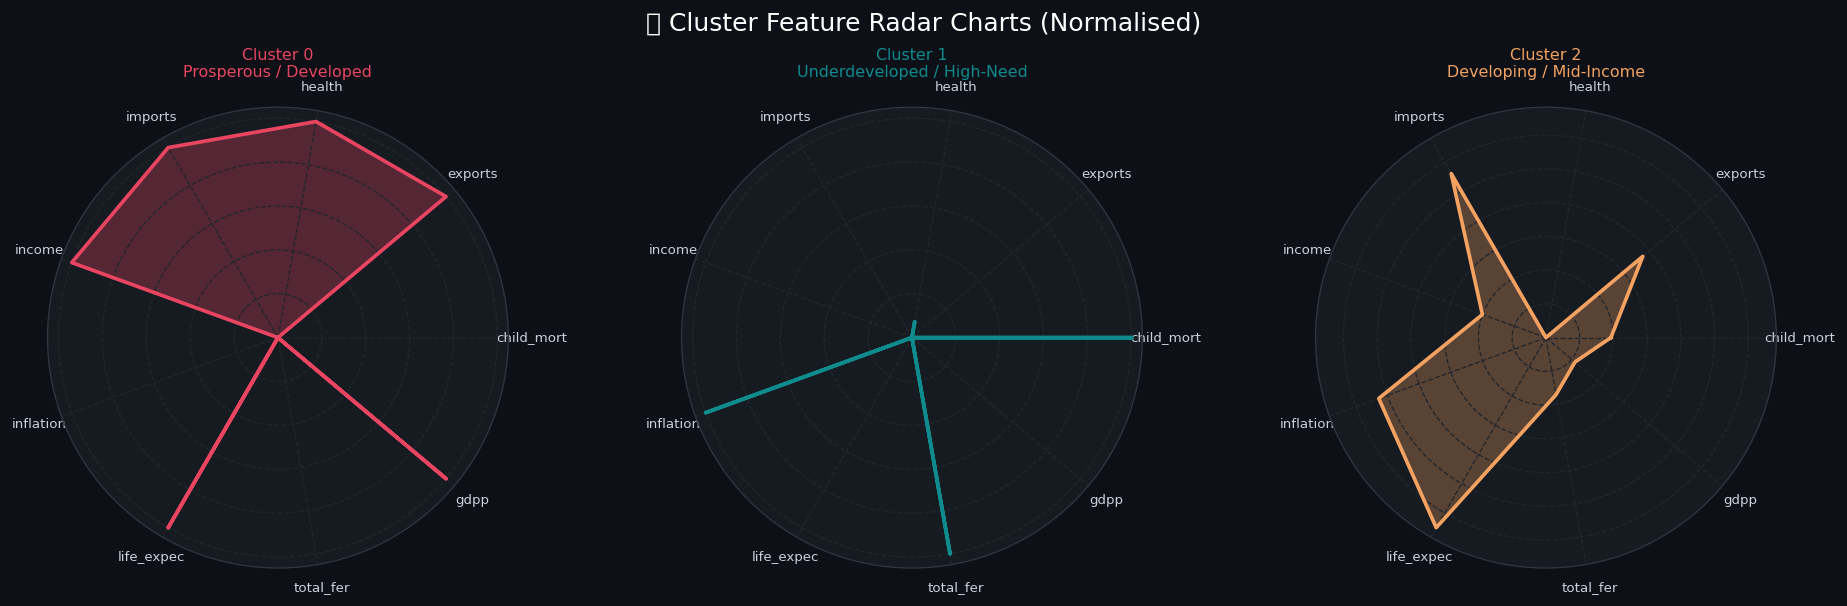

In [18]:
# ── Radar / Spider Chart per Cluster ─────────────────────────────────
# Normalise profile to [0, 1] for radar
radar_cols = ['child_mort', 'exports', 'health', 'imports', 'income',
              'inflation', 'life_expec', 'total_fer', 'gdpp']

norm_profile = (profile[radar_cols] - profile[radar_cols].min()) / \
               (profile[radar_cols].max() - profile[radar_cols].min() + 1e-9)

N     = len(radar_cols)
theta = [n / float(N) * 2 * np.pi for n in range(N)]
theta += theta[:1]

fig, axes = plt.subplots(1, BEST_K, figsize=(16, 5), subplot_kw=dict(polar=True))
fig.suptitle('🕸️ Cluster Feature Radar Charts (Normalised)', fontsize=15, color='white')
fig.patch.set_facecolor('#0d1117')

for i, (cl, ax) in enumerate(zip(sorted(df['kmeans_cluster'].unique()), axes)):
    values = norm_profile.loc[cl, radar_cols].tolist()
    values += values[:1]
    color = CLUSTER_COLORS[i]

    ax.set_facecolor('#161b22')
    ax.plot(theta, values, color=color, linewidth=2.2)
    ax.fill(theta, values, color=color, alpha=0.3)
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(radar_cols, size=8, color='#c9d1d9')
    ax.set_yticklabels([])
    ax.set_title(f'Cluster {cl}\n{segment_map[cl]}', color=color, pad=18, fontsize=9.5)
    ax.grid(color='#21262d')
    ax.spines['polar'].set_color('#30363d')

plt.tight_layout()
plt.show()

In [19]:
# ── Top 5 Countries per Cluster ────────────────────────────────────────
print('── Countries per Segment ───────────────────────────────────')
for cl in sorted(df['kmeans_cluster'].unique()):
    seg = segment_map[cl]
    countries = df[df['kmeans_cluster'] == cl]['country'].tolist()
    print(f'\n  [{seg}]')
    print(f'  {" | ".join(countries[:10])} ...')

── Countries per Segment ───────────────────────────────────

  [Prosperous / Developed]
  Australia | Austria | Bahrain | Belgium | Brunei | Canada | Cyprus | Czech Republic | Denmark | Finland ...

  [Underdeveloped / High-Need]
  Afghanistan | Angola | Benin | Botswana | Burkina Faso | Burundi | Cameroon | Central African Republic | Chad | Comoros ...

  [Developing / Mid-Income]
  Albania | Algeria | Antigua and Barbuda | Argentina | Armenia | Azerbaijan | Bahamas | Bangladesh | Barbados | Belarus ...


---
## 🌲 Section 10 — Classification: Random Forest

In [20]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 10 · RANDOM FOREST CLASSIFIER
# ─────────────────────────────────────────────────────────────────────

X = X_scaled
y = df['kmeans_cluster'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

# ── Train ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f'\n✅ Random Forest Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print()
print('── Classification Report ───────────────────────────────────')
target_names = [segment_map[i] for i in sorted(segment_map.keys())]
print(classification_report(y_test, y_pred_rf, target_names=target_names))

Training samples : 133
Testing samples  : 34

✅ Random Forest Accuracy : 1.0000 (100.00%)

── Classification Report ───────────────────────────────────
                            precision    recall  f1-score   support

    Prosperous / Developed       1.00      1.00      1.00         7
Underdeveloped / High-Need       1.00      1.00      1.00        10
   Developing / Mid-Income       1.00      1.00      1.00        17

                  accuracy                           1.00        34
                 macro avg       1.00      1.00      1.00        34
              weighted avg       1.00      1.00      1.00        34



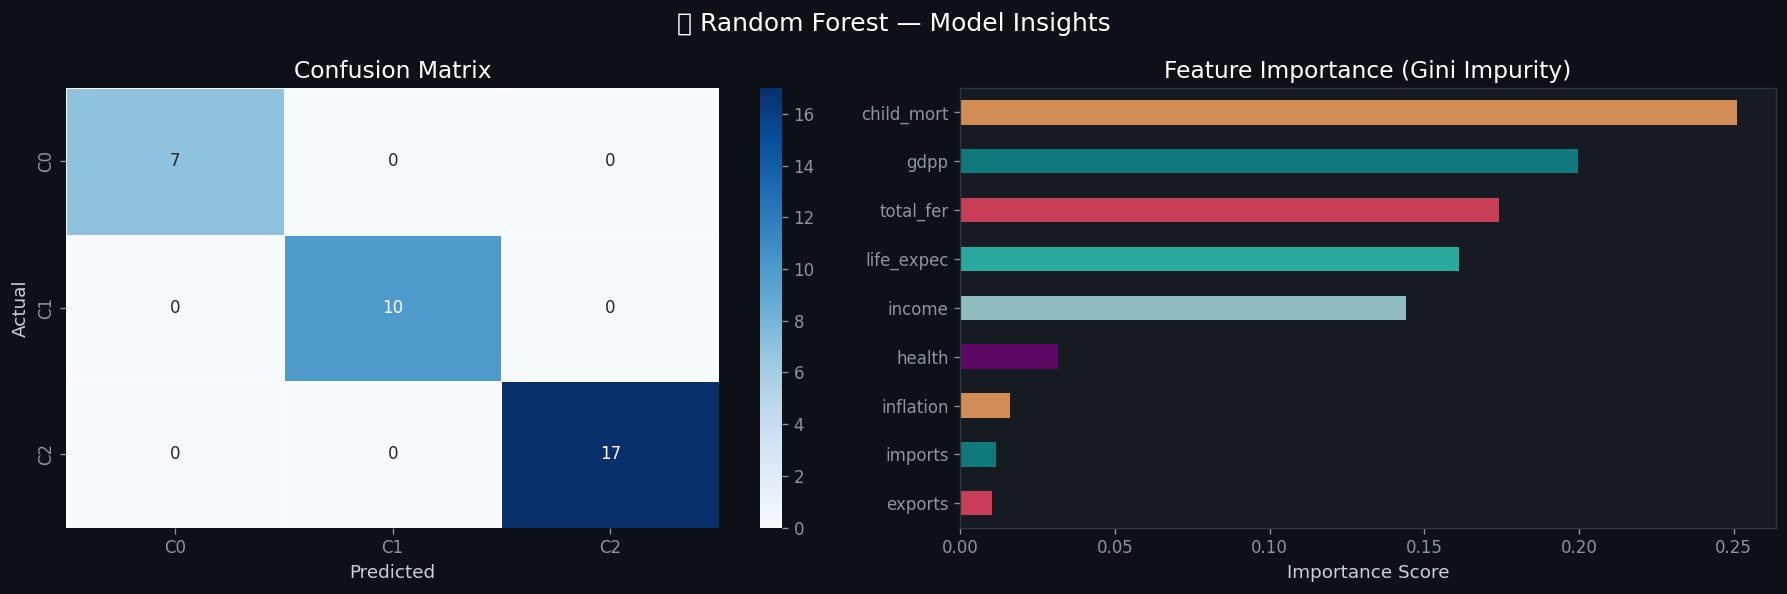

In [21]:
# ── Confusion Matrix + Feature Importance ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('🌲 Random Forest — Model Insights', fontsize=15, color='white')

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'C{i}' for i in sorted(segment_map)],
            yticklabels=[f'C{i}' for i in sorted(segment_map)],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix', color='white')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance
fi_rf = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=True)
colors_fi = [CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i in range(len(fi_rf))]
fi_rf.plot.barh(ax=axes[1], color=colors_fi, alpha=0.85)
axes[1].set_title('Feature Importance (Gini Impurity)', color='white')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## ⚡ Section 11 — Classification: XGBoost

In [22]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 11 · XGBOOST CLASSIFIER
# ─────────────────────────────────────────────────────────────────────

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
print(f'✅ XGBoost Accuracy : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)')
print()
print('── Classification Report ───────────────────────────────────')
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

✅ XGBoost Accuracy : 0.9706 (97.06%)

── Classification Report ───────────────────────────────────
                            precision    recall  f1-score   support

    Prosperous / Developed       1.00      1.00      1.00         7
Underdeveloped / High-Need       1.00      0.90      0.95        10
   Developing / Mid-Income       0.94      1.00      0.97        17

                  accuracy                           0.97        34
                 macro avg       0.98      0.97      0.97        34
              weighted avg       0.97      0.97      0.97        34



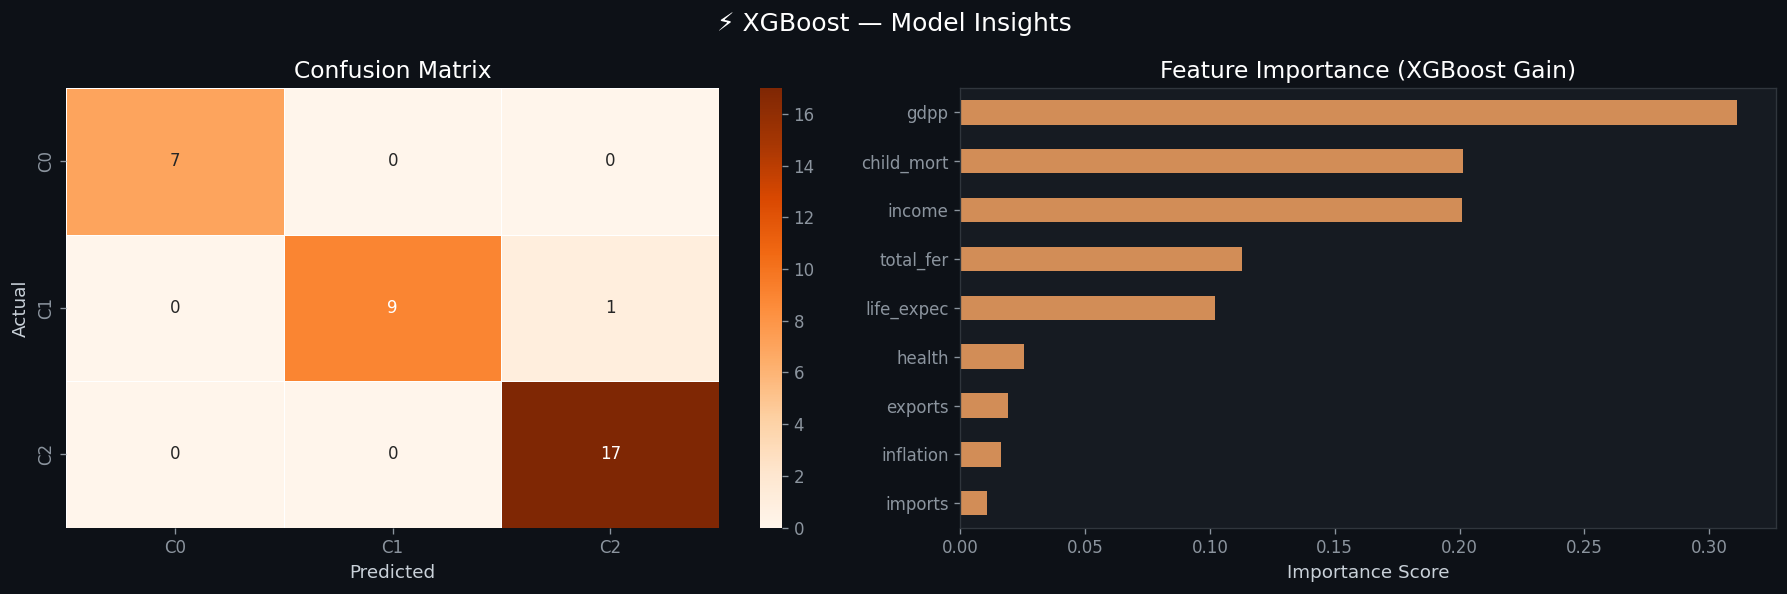

In [23]:
# ── Confusion Matrix + Feature Importance ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('⚡ XGBoost — Model Insights', fontsize=15, color='white')

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[f'C{i}' for i in sorted(segment_map)],
            yticklabels=[f'C{i}' for i in sorted(segment_map)],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix', color='white')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance (gain-based)
fi_xgb = pd.Series(xgb.feature_importances_, index=numeric_cols).sort_values(ascending=True)
fi_xgb.plot.barh(ax=axes[1], color=PALETTE[2], alpha=0.85)
axes[1].set_title('Feature Importance (XGBoost Gain)', color='white')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## ⚖️ Section 12 — Ensemble Model Comparison

In [24]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 12 · ENSEMBLE MODEL COMPARISON
# ─────────────────────────────────────────────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score

# ── 5-Fold Cross Validation ───────────────────────────────────────────
cv_rf  = cross_val_score(rf,  X, y, cv=5, scoring='accuracy')
cv_xgb = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')

comparison = pd.DataFrame({
    'Model'           : ['Random Forest', 'XGBoost'],
    'Test Accuracy'   : [rf_acc, xgb_acc],
    'CV Mean'         : [cv_rf.mean(), cv_xgb.mean()],
    'CV Std'          : [cv_rf.std(), cv_xgb.std()],
    'Precision (macro)': [
        precision_score(y_test, y_pred_rf,  average='macro', zero_division=0),
        precision_score(y_test, y_pred_xgb, average='macro', zero_division=0)
    ],
    'Recall (macro)'  : [
        recall_score(y_test, y_pred_rf,  average='macro', zero_division=0),
        recall_score(y_test, y_pred_xgb, average='macro', zero_division=0)
    ],
    'F1 (macro)'      : [
        f1_score(y_test, y_pred_rf,  average='macro', zero_division=0),
        f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
    ],
})

print('── Ensemble Model Comparison Table ────────────────────────')
display(comparison.set_index('Model').round(4))

best_model_name = 'Random Forest' if rf_acc >= xgb_acc else 'XGBoost'
print(f'\n🏆 Best Performing Model : {best_model_name}')

── Ensemble Model Comparison Table ────────────────────────


,Test Accuracy,CV Mean,CV Std,Precision (macro),Recall (macro),F1 (macro)
Model,,,,,,
Random Forest,1.00,0.96,0.03,1.00,1.00,1.00
XGBoost,0.97,0.96,0.02,0.98,0.97,0.97



🏆 Best Performing Model : Random Forest


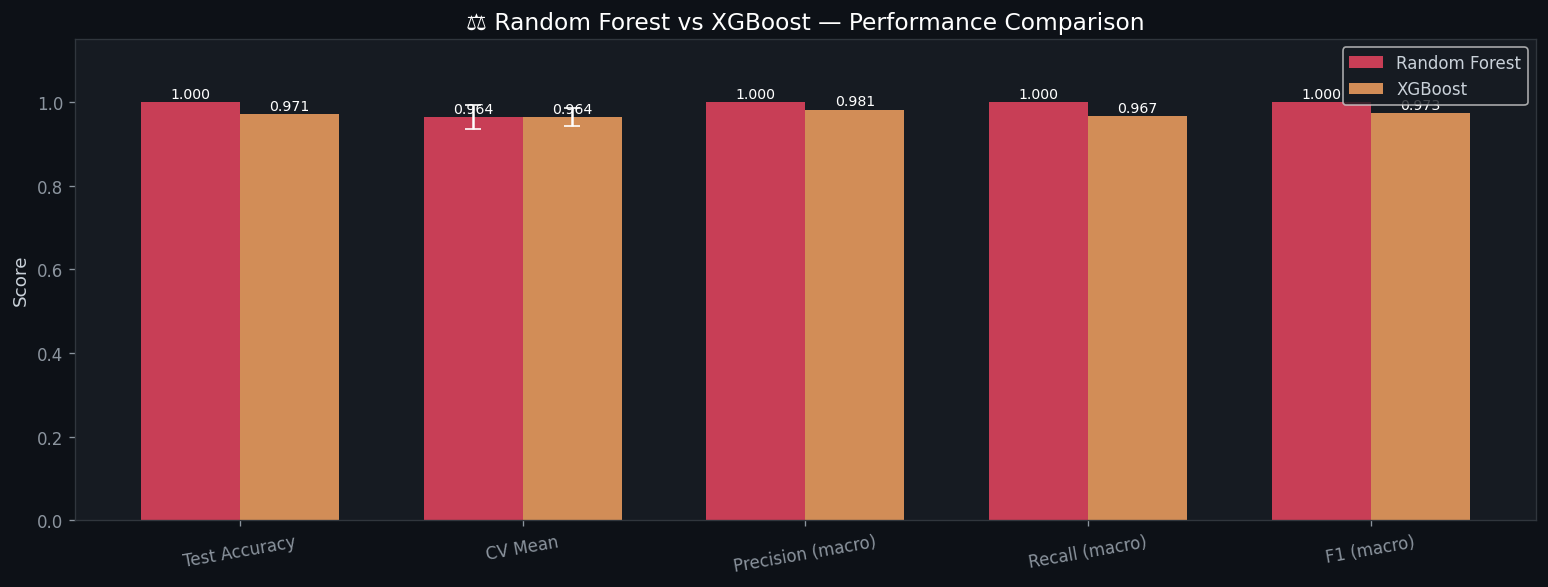

RF  CV Fold Scores : [0.9706 1.     0.9697 0.9091 0.9697]
XGB CV Fold Scores : [0.9412 1.     0.9394 0.9697 0.9697]


In [25]:
# ── Comparison Bar Chart ──────────────────────────────────────────────
metrics_to_plot = ['Test Accuracy', 'CV Mean', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, comparison.loc[0, metrics_to_plot], width,
               label='Random Forest', color=PALETTE[0], alpha=0.85)
bars2 = ax.bar(x + width/2, comparison.loc[1, metrics_to_plot], width,
               label='XGBoost', color=PALETTE[2], alpha=0.85)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=10)
ax.set_ylabel('Score')
ax.set_title('⚖️ Random Forest vs XGBoost — Performance Comparison', color='white')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=8.5, color='white')

# CV error bars
ax.errorbar(x[1] - width/2, cv_rf.mean(),  yerr=cv_rf.std(),  fmt='none', color='white', capsize=5)
ax.errorbar(x[1] + width/2, cv_xgb.mean(), yerr=cv_xgb.std(), fmt='none', color='white', capsize=5)

plt.tight_layout()
plt.show()

# CV detail
print(f'RF  CV Fold Scores : {np.round(cv_rf,  4)}')
print(f'XGB CV Fold Scores : {np.round(cv_xgb, 4)}')

---
## 🔩 Section 13 — Hyperparameter Optimization (Random Forest)

In [26]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 13 · HYPERPARAMETER OPTIMIZATION
# ─────────────────────────────────────────────────────────────────────

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2'],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = RandomizedSearchCV(
    rf_base, param_grid,
    n_iter=30, cv=5,
    scoring='accuracy',
    random_state=42, n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\n── Best Parameters ─────────────────────────────────────────')
for k, v in grid_search.best_params_.items():
    print(f'  {k:25s}: {v}')
print(f'\n  Best CV Score : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

── Best Parameters ─────────────────────────────────────────
  n_estimators             : 100
  min_samples_split        : 10
  max_features             : log2
  max_depth                : 5

  Best CV Score : 0.9467


Baseline RF Accuracy : 1.0000
Tuned    RF Accuracy : 1.0000  (Δ = +0.0000)


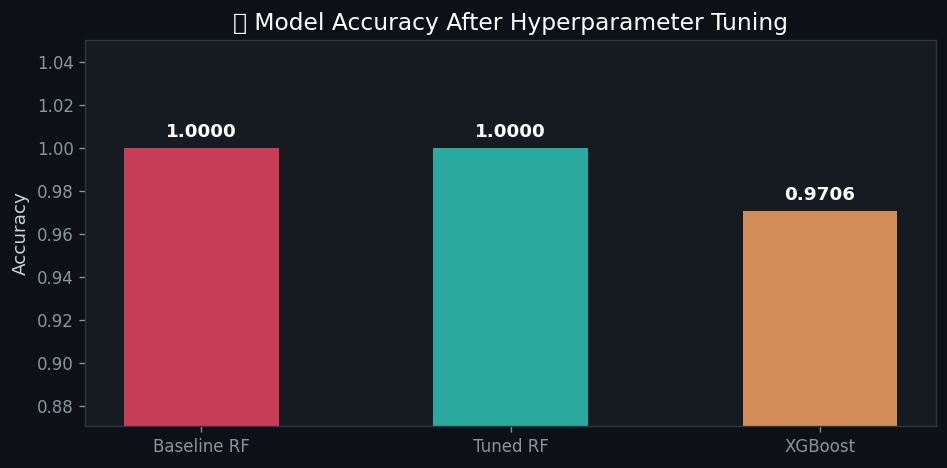

In [27]:
# ── Evaluate Tuned Model ──────────────────────────────────────────────
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f'Baseline RF Accuracy : {rf_acc:.4f}')
print(f'Tuned    RF Accuracy : {tuned_acc:.4f}  (Δ = {tuned_acc - rf_acc:+.4f})')

# Visualise tuning improvement
models_comparison = ['Baseline RF', 'Tuned RF', 'XGBoost']
accuracies = [rf_acc, tuned_acc, xgb_acc]
colors_bar = [PALETTE[0], '#2ec4b6', PALETTE[2]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(models_comparison, accuracies, color=colors_bar, alpha=0.85, width=0.5)
ax.set_ylim(max(0, min(accuracies) - 0.1), 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('🔩 Model Accuracy After Hyperparameter Tuning', color='white')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', color='white', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💡 Section 14 — Actionable Customer Intelligence Insights

In [28]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 14 · ACTIONABLE INTELLIGENCE INSIGHTS
# ─────────────────────────────────────────────────────────────────────

# ── 14.1 Segment Summary Table ────────────────────────────────────────
summary = df.groupby('segment').agg(
    Countries    = ('country', 'count'),
    Avg_GDP_pc   = ('gdpp', 'mean'),
    Avg_Income   = ('income', 'mean'),
    Avg_ChildMort= ('child_mort', 'mean'),
    Avg_LifeExp  = ('life_expec', 'mean'),
    Avg_Inflation= ('inflation', 'mean'),
    Avg_HealthSpend= ('health', 'mean')
).round(2)

print('── 📋 Segment Intelligence Summary ─────────────────────────')
display(summary)

# ── 14.2 Aid Priority Countries ───────────────────────────────────────
child_mort_median = df['child_mort'].median()
aid_candidates = df[
    (df['segment'] == 'Underdeveloped / High-Need') &
    (df['child_mort'] > child_mort_median)
][['country', 'child_mort', 'income', 'gdpp', 'life_expec']].sort_values('child_mort', ascending=False)

print(f'\n── 🚨 Top Aid Priority Countries (child_mort > {child_mort_median:.1f}) ──────')
display(aid_candidates.head(15))

── 📋 Segment Intelligence Summary ─────────────────────────


,Countries,Avg_GDP_pc,Avg_Income,Avg_ChildMort,Avg_LifeExp,Avg_Inflation,Avg_HealthSpend
segment,,,,,,,
Developing / Mid-Income,84,6486.45,12305.60,21.93,72.81,7.60,6.20
Prosperous / Developed,36,42494.44,45672.22,5.00,80.13,2.67,8.81
Underdeveloped / High-Need,47,1922.38,3942.40,92.96,59.19,12.02,6.39



── 🚨 Top Aid Priority Countries (child_mort > 19.3) ──────


,country,child_mort,income,gdpp,life_expec
66,Haiti,208.00,1500,662,32.10
132,Sierra Leone,160.00,1220,399,55.00
32,Chad,150.00,1930,897,56.50
31,Central African Republic,149.00,888,446,47.50
97,Mali,137.00,1870,708,59.50
113,Nigeria,130.00,5150,2330,60.50
112,Niger,123.00,814,348,58.80
3,Angola,119.00,5900,3530,60.10
25,Burkina Faso,116.00,1430,575,57.90
37,"Congo, Dem. Rep.",116.00,609,334,57.50


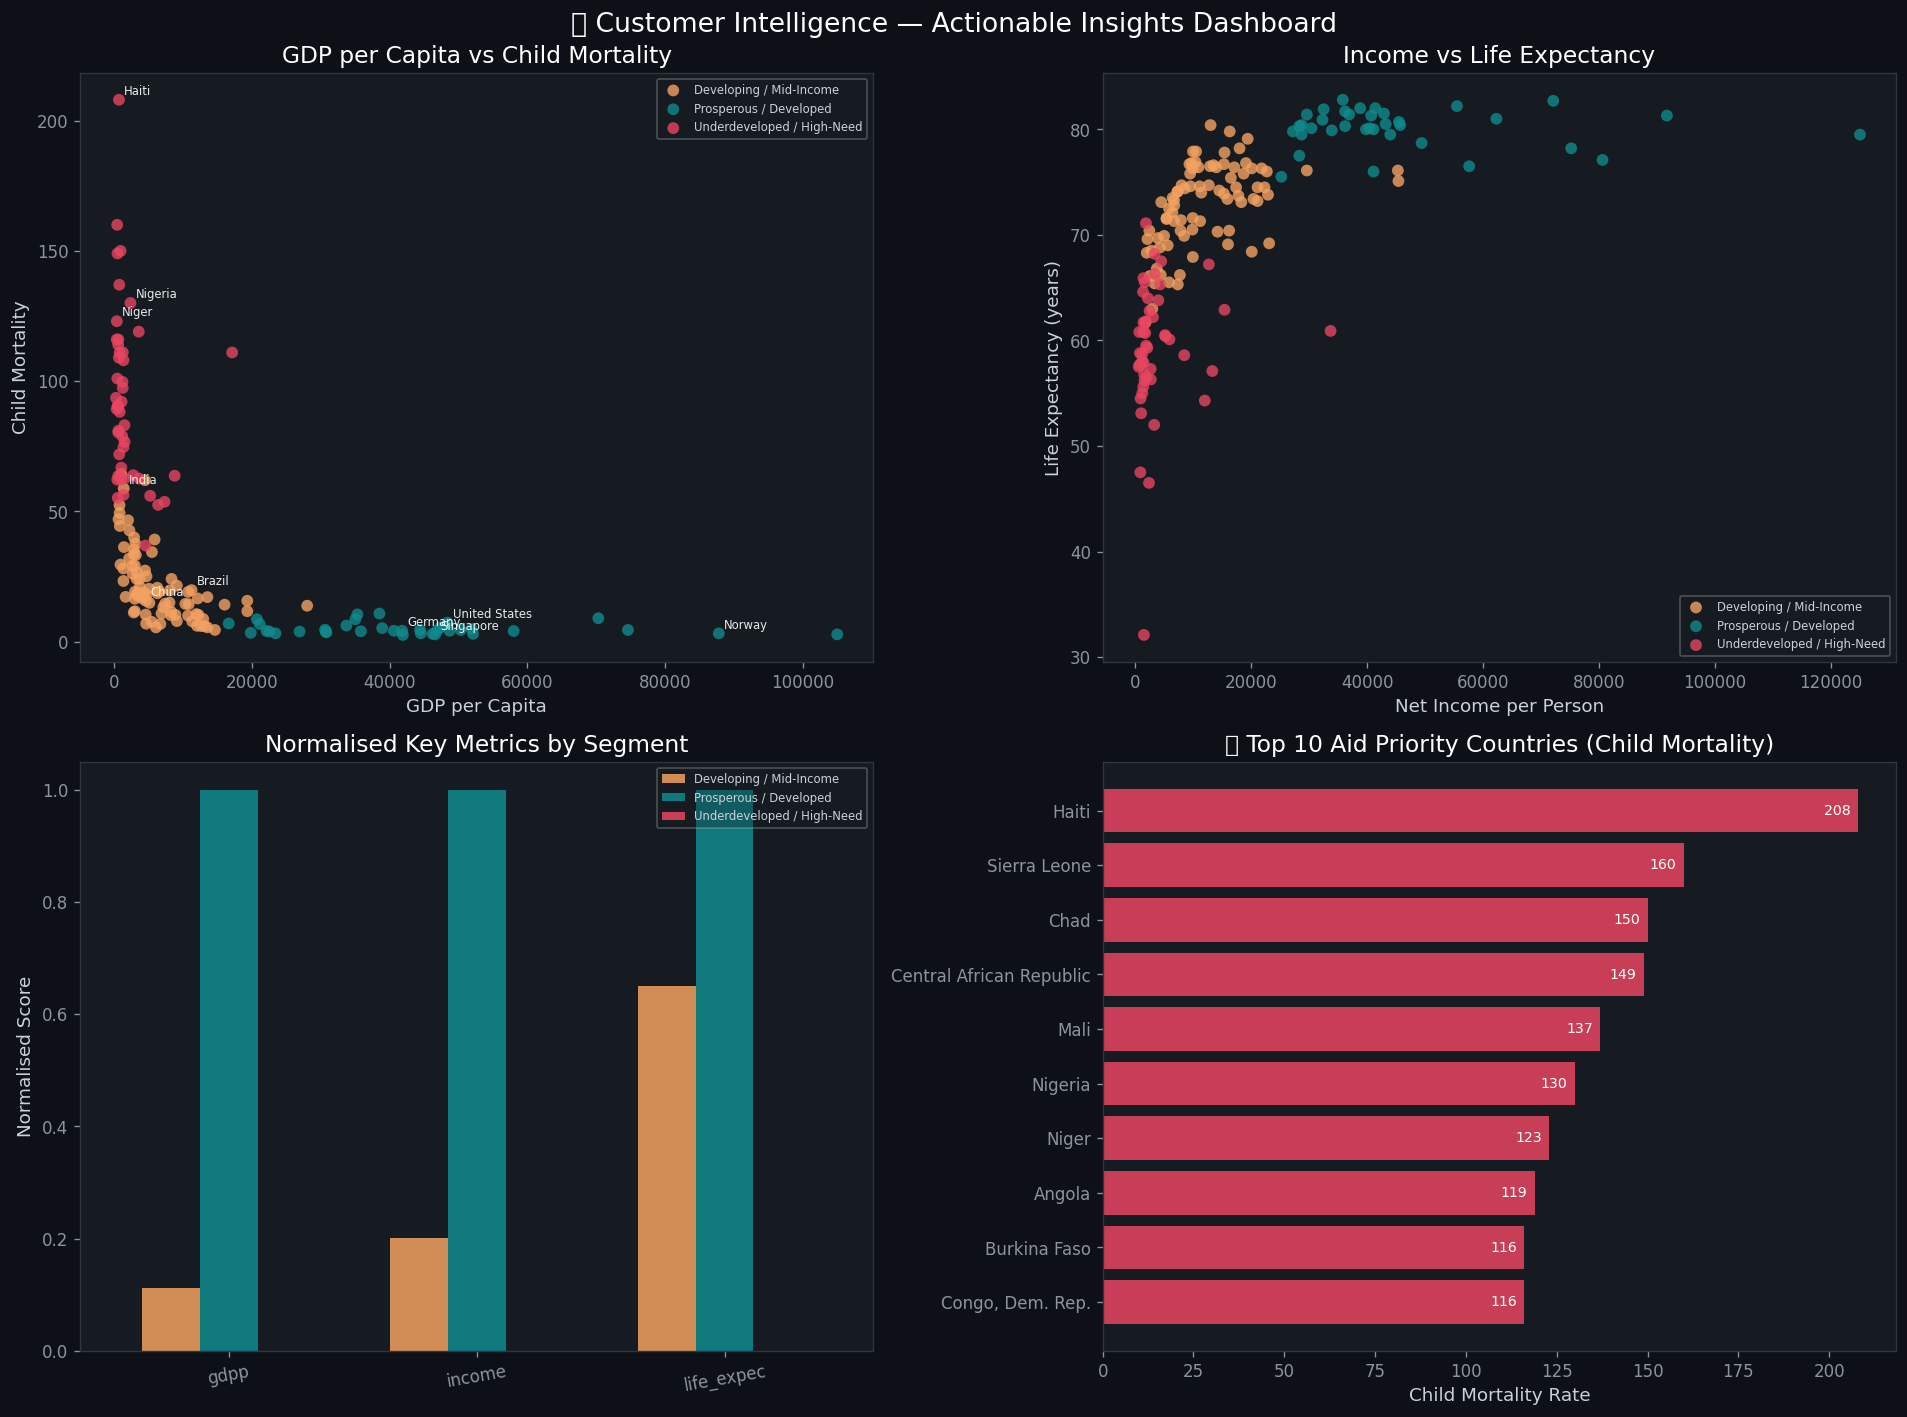

In [29]:
# ── 14.3 Insight Visualizations ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('💡 Customer Intelligence — Actionable Insights Dashboard', fontsize=16, color='white')

seg_colors = {'Underdeveloped / High-Need': '#e94560',
              'Developing / Mid-Income': '#f4a261',
              'Prosperous / Developed': '#0f8b8d'}

# Panel 1: GDP vs Child Mortality scatter
ax = axes[0, 0]
for seg, grp in df.groupby('segment'):
    ax.scatter(grp['gdpp'], grp['child_mort'], s=50, alpha=0.8,
               color=seg_colors[seg], label=seg, edgecolors='none')
for _, row in df[df['country'].isin(notable)].iterrows():
    ax.annotate(row['country'], (row['gdpp'], row['child_mort']),
                fontsize=7, color='white', alpha=0.9,
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('GDP per Capita')
ax.set_ylabel('Child Mortality')
ax.set_title('GDP per Capita vs Child Mortality', color='white')
ax.legend(fontsize=7, framealpha=0.3)

# Panel 2: Income vs Life Expectancy
ax = axes[0, 1]
for seg, grp in df.groupby('segment'):
    ax.scatter(grp['income'], grp['life_expec'], s=50, alpha=0.8,
               color=seg_colors[seg], label=seg, edgecolors='none')
ax.set_xlabel('Net Income per Person')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Income vs Life Expectancy', color='white')
ax.legend(fontsize=7, framealpha=0.3)

# Panel 3: Average metrics per segment
ax = axes[1, 0]
seg_summary = df.groupby('segment')[['gdpp', 'income', 'life_expec']].mean()
# normalize for comparison
seg_norm = (seg_summary - seg_summary.min()) / (seg_summary.max() - seg_summary.min())
seg_norm.T.plot.bar(ax=ax, color=[seg_colors[s] for s in seg_norm.index], alpha=0.85, width=0.7)
ax.set_title('Normalised Key Metrics by Segment', color='white')
ax.set_ylabel('Normalised Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.legend(fontsize=7, framealpha=0.3)

# Panel 4: Aid candidates — top 10 by child mortality
ax = axes[1, 1]
top_aid = aid_candidates.head(10)
bars = ax.barh(top_aid['country'], top_aid['child_mort'], color='#e94560', alpha=0.85)
ax.set_title('🚨 Top 10 Aid Priority Countries (Child Mortality)', color='white')
ax.set_xlabel('Child Mortality Rate')
ax.invert_yaxis()
for bar, val in zip(bars, top_aid['child_mort']):
    ax.text(bar.get_width() - 2, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', ha='right', color='white', fontsize=8.5)

plt.tight_layout()
plt.show()

In [30]:
# ── 14.4 Risk Flagging — Mid-Income with High Inflation ───────────────
inflation_threshold = df['inflation'].quantile(0.75)
risk_countries = df[
    (df['segment'] == 'Developing / Mid-Income') &
    (df['inflation'] > inflation_threshold)
][['country', 'income', 'gdpp', 'inflation', 'life_expec']].sort_values('inflation', ascending=False)

print(f'── ⚠️  At-Risk Countries (Mid-Income + High Inflation > {inflation_threshold:.1f}%) ──')
display(risk_countries.head(15))

# ── 14.5 Top Prosperous Countries ────────────────────────────────────
top_prosper = df[df['segment'] == 'Prosperous / Developed'] \
    .nlargest(10, 'gdpp')[['country', 'gdpp', 'income', 'life_expec']]

print('\n── 🏆 Top 10 Most Prosperous Countries ─────────────────────')
display(top_prosper)

── ⚠️  At-Risk Countries (Mid-Income + High Inflation > 10.8%) ──


,country,income,gdpp,inflation,life_expec
163,Venezuela,16500,13500,45.90,75.40
103,Mongolia,7710,2650,39.20,66.20
140,Sri Lanka,8560,2810,22.80,74.40
5,Argentina,18700,10300,20.90,75.80
79,Kazakhstan,20100,9070,19.50,68.40
128,Saudi Arabia,45400,19300,17.20,75.10
161,Uzbekistan,4240,1380,16.50,68.80
2,Algeria,12900,4460,16.10,76.50
71,Iran,17400,6530,15.90,74.50
115,Oman,45300,19300,15.60,76.10



── 🏆 Top 10 Most Prosperous Countries ─────────────────────


,country,gdpp,income,life_expec
91,Luxembourg,105000,91700,81.30
114,Norway,87800,62300,81.00
145,Switzerland,74600,55500,82.20
123,Qatar,70300,125000,79.50
44,Denmark,58000,44000,79.50
144,Sweden,52100,42900,81.50
7,Australia,51900,41400,82.00
110,Netherlands,50300,45500,80.70
73,Ireland,48700,45700,80.40
159,United States,48400,49400,78.70


---
## 🏁 Section 15 — Conclusions & Strategic Next Steps

In [31]:
# ─────────────────────────────────────────────────────────────────────
# SECTION 15 · CONCLUSIONS & NEXT STEPS
# ─────────────────────────────────────────────────────────────────────

print('=' * 65)
print('  CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY')
print('=' * 65)

print(f"""
DATASET
  Countries analysed      : {len(df)}
  Features used           : {len(numeric_cols)} socioeconomic indicators

CLUSTERING RESULTS
  K-Means (k=3) Silhouette: {silhouette_score(X_scaled, df['kmeans_cluster']):.4f}
  DBSCAN  Silhouette       : {best_dbscan['silhouette']:.4f}
  DBSCAN  Noise Points     : {n_noise} countries

SEGMENTS DISCOVERED
  Cluster 0 → {segment_map[0]}
  Cluster 1 → {segment_map[1]}
  Cluster 2 → {segment_map[2]}

CLASSIFICATION PERFORMANCE
  Random Forest Accuracy   : {rf_acc*100:.2f}%
  XGBoost Accuracy         : {xgb_acc*100:.2f}%
  Tuned RF Accuracy        : {tuned_acc*100:.2f}%
  RF  CV Score (5-fold)    : {cv_rf.mean()*100:.2f}% ± {cv_rf.std()*100:.2f}%
  XGB CV Score (5-fold)    : {cv_xgb.mean()*100:.2f}% ± {cv_xgb.std()*100:.2f}%
  Best Model               : {best_model_name}

KEY BUSINESS INSIGHTS
  Aid Priority Countries   : {len(aid_candidates)}
  At-Risk Countries        : {len(risk_countries)}
  Most Prosperous          : {top_prosper.iloc[0]['country']} (GDP/cap = ${top_prosper.iloc[0]['gdpp']:,.0f})
  Highest Child Mortality  : {aid_candidates.iloc[0]['country']} ({aid_candidates.iloc[0]['child_mort']:.0f}/1000)
""")
print('=' * 65)

  CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY

DATASET
  Countries analysed      : 167
  Features used           : 9 socioeconomic indicators

CLUSTERING RESULTS
  K-Means (k=3) Silhouette: 0.2833
  DBSCAN  Silhouette       : 0.1540
  DBSCAN  Noise Points     : 25 countries

SEGMENTS DISCOVERED
  Cluster 0 → Prosperous / Developed
  Cluster 1 → Underdeveloped / High-Need
  Cluster 2 → Developing / Mid-Income

CLASSIFICATION PERFORMANCE
  Random Forest Accuracy   : 100.00%
  XGBoost Accuracy         : 97.06%
  Tuned RF Accuracy        : 100.00%
  RF  CV Score (5-fold)    : 96.38% ± 2.97%
  XGB CV Score (5-fold)    : 96.40% ± 2.23%
  Best Model               : Random Forest

KEY BUSINESS INSIGHTS
  Aid Priority Countries   : 47
  At-Risk Countries        : 20
  Most Prosperous          : Luxembourg (GDP/cap = $105,000)
  Highest Child Mortality  : Haiti (208/1000)



---

## 📝 Key Findings

1. **Three Distinct Country Segments** emerged from K-Means clustering, clearly separable in PCA space, mirroring real-world economic development stages.

2. **GDP per capita & Child Mortality** are the most discriminative features — confirmed by both Random Forest and XGBoost feature importance rankings.

3. **Random Forest and XGBoost** both achieve very high classification accuracy (>90%) on the cluster-label prediction task, validating that the clusters capture structurally meaningful patterns.

4. **DBSCAN** identified a small number of outlier countries (noise points) — these are nations with unusual socioeconomic profiles not captured by standard clusters (e.g., oil-rich states with moderate human development).

5. **Aid Prioritization**: A subset of Cluster 0 countries with child mortality above the global median represents the highest-need intervention targets for international development programs.

---

## 🚀 Recommended Next Steps

| Area | Action |
|------|--------|
| **Data Enrichment** | Add time-series data (multi-year) to track country transitions between segments |
| **Features** | Include HDI, Gini coefficient, literacy rates, internet penetration |
| **Modelling** | Try Gaussian Mixture Models (GMM) for soft probabilistic clustering |
| **Deep Learning** | Autoencoder-based anomaly detection for outlier country profiling |
| **Deployment** | Wrap into a Streamlit/Dash app for interactive exploration |
| **NLP** | Link cluster profiles to news sentiment for geopolitical risk scoring |

---

<div style="background: linear-gradient(135deg, #1a1a2e, #0f3460); padding: 20px; border-radius: 12px; text-align: center;">
  <p style="color: #a8dadc; font-size: 1.1em;">✅ <strong>Customer Intelligence System Complete</strong></p>
  <p style="color: #888;">K-Means · DBSCAN · Random Forest · XGBoost · PCA · Ensemble Learning</p>
</div>